In [1]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt

from pyproj import Geod
from shapely.geometry import MultiPoint
from shapely.geometry import Point, LineString, Polygon


import contextily as ctx


In [10]:
df = pd.read_csv('./bin/Debug/net5.0/Commuter.csv')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Tick                 9000 non-null   int64  
 1   Step                 9000 non-null   int64  
 2   DateTime             9000 non-null   object 
 3   CarVelocity          9000 non-null   float64
 4   CurrentlyCarDriving  9000 non-null   bool   
 5   GoalReached          9000 non-null   bool   
 6   MyMass               9000 non-null   int64  
 7   OvertakingActivated  9000 non-null   bool   
 8   StableId             9000 non-null   int64  
 9   X                    9000 non-null   float64
 10  Y                    9000 non-null   float64
 11  ID                   9000 non-null   object 
dtypes: bool(3), float64(3), int64(4), object(2)
memory usage: 659.3+ KB


In [17]:
df.head(-1)

,Tick,Step,DateTime,CarVelocity,CurrentlyCarDriving,GoalReached,MyMass,OvertakingActivated,StableId,X,Y,ID
0,601,601,2019-01-01T07:10:01.0000000+01:00,0.73,True,False,0,False,0,31.532589,-25.462490,eb644fbe-0e7d-476c-bf11-fb5e601cf287
1,602,602,2019-01-01T07:10:02.0000000+01:00,1.46,True,False,0,False,0,31.532580,-25.462501,eb644fbe-0e7d-476c-bf11-fb5e601cf287
2,603,603,2019-01-01T07:10:03.0000000+01:00,2.19,True,False,0,False,0,31.532567,-25.462516,eb644fbe-0e7d-476c-bf11-fb5e601cf287
3,604,604,2019-01-01T07:10:04.0000000+01:00,2.92,True,False,0,False,0,31.532550,-25.462537,eb644fbe-0e7d-476c-bf11-fb5e601cf287
4,605,605,2019-01-01T07:10:05.0000000+01:00,3.65,True,False,0,False,0,31.532527,-25.462563,eb644fbe-0e7d-476c-bf11-fb5e601cf287
...,...,...,...,...,...,...,...,...,...,...,...,...
8994,3599,3599,2019-01-01T07:59:59.0000000+01:00,11.10,True,False,0,False,0,31.486495,-25.461443,eafbdbf5-488e-4869-bffc-5d3e604753ad
8995,3600,3600,2019-01-01T08:00:00.0000000+01:00,0.00,True,True,0,False,0,31.440795,-25.413202,23c45065-8832-490d-9de2-cb5993e7959a
8996,3600,3600,2019-01-01T08:00:00.0000000+01:00,0.00,True,True,0,False,0,31.440795,-25.413202,eb644fbe-0e7d-476c-bf11-fb5e601cf287
8997,3600,3600,2019-01-01T08:00:00.0000000+01:00,0.00,True,True,0,False,0,31.440795,-25.413202,6d29b4e3-843f-415a-a73a-e2b8db6edcf7


In [13]:
ids = list(df['ID'].unique())

In [8]:
df2 = df[df['GoalReached'] == True]

In [14]:
df2  = df[df['ID'] == ids[0]]

<AxesSubplot:>

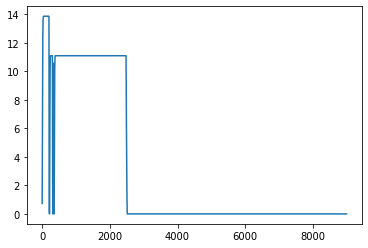

In [16]:
df2['CarVelocity'].plot()

p


Text(0, 0.5, 'm/s')

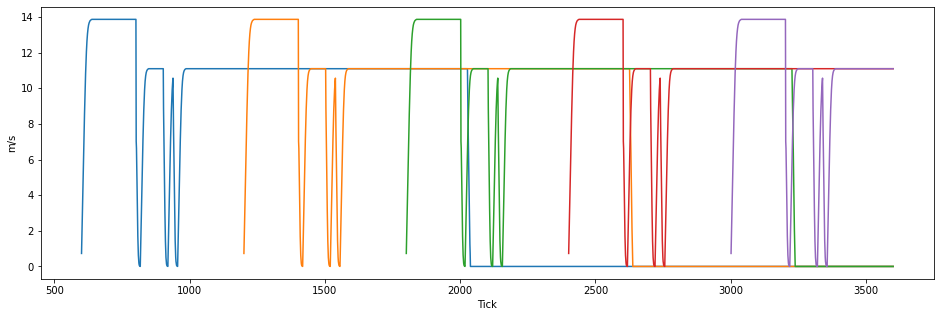

In [19]:
fig, ax = plt.subplots(figsize=(16, 5))




for i in ids:
    df2  = df[df['ID'] == i]
    ax.plot(df2['Tick'], df2['CarVelocity'], label=i)



plt.xlabel('Tick')
plt.ylabel('m/s')